# EDA and analyst insights

Exploratory data analysis over the vulnerability dataset. Reads `data/sample_data.csv` by default — the same 50-row snapshot used by `dashboard_preview.ipynb` — but the code below works unchanged on a full export from `report_cve_daily`. Swap the `CSV_PATH` (or replace the load cell with a `pd.read_sql(...)` call against your local Postgres) to run against real data.

The notebook ends with three analyst-style insights that explain what the data *means* for operations, not just what's in it.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Load and inspect

Start with the cheapest checks — shape, types, a head — before trusting anything downstream.

In [2]:
def _resolve_sample_csv() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd / "data" / "sample_data.csv", cwd.parent / "data" / "sample_data.csv"):
        if p.is_file():
            return p
    raise FileNotFoundError(
        "Cannot find data/sample_data.csv — open Jupyter with project root or notebooks/ as cwd."
    )

CSV_PATH = _resolve_sample_csv()
df = pd.read_csv(CSV_PATH, parse_dates=["as_of_date", "date_added"])
print(f"Shape: {df.shape}")
print(f"Date window: {df['as_of_date'].min().date()} → {df['as_of_date'].max().date()}")
df.dtypes

Shape: (50, 11)
Date window: 2026-04-19 → 2026-04-19


as_of_date    datetime64[ns]
cve_id                object
severity              object
cvss_score           float64
is_kev                  bool
epss_score           float64
age_days               int64
risk_score           float64
vendor                object
product               object
date_added    datetime64[ns]
dtype: object

In [3]:
df.head()

,as_of_date,cve_id,severity,cvss_score,is_kev,epss_score,age_days,risk_score,vendor,product,date_added
0,2026-04-19,CVE-2024-0001,Critical,9.8,True,0.95,60,11.27,microsoft,windows,2026-02-15
1,2026-04-19,CVE-2024-0002,High,8.1,False,0.42,120,6.54,microsoft,windows,NaT
2,2026-04-19,CVE-2024-0003,Critical,9.1,True,0.87,90,10.89,microsoft,office,2026-01-20
3,2026-04-19,CVE-2024-0004,High,7.5,False,0.35,45,5.20,microsoft,office,NaT
4,2026-04-19,CVE-2024-0005,Medium,5.5,False,0.12,200,4.80,microsoft,windows,NaT


## 2. Descriptive statistics

`describe()` on the numeric columns — a sanity check on ranges. CVSS should be 0–10, EPSS 0–1, risk score roughly 0–15 given the current weights.

In [4]:
df[["cvss_score", "epss_score", "age_days", "risk_score"]].describe().round(2)

,cvss_score,epss_score,age_days,risk_score
count,50.00,50.00,50.00,50.00
mean,6.60,0.37,155.60,6.53
std,2.02,0.31,92.00,2.96
min,2.80,0.03,30.00,3.59
25%,5.43,0.12,81.25,4.46
50%,6.50,0.24,127.50,5.24
75%,8.07,0.54,217.50,6.93
max,9.80,0.99,370.00,14.42


## 3. Missing data audit

Empty `date_added` on non-KEV rows is expected. Nulls anywhere else are a data-quality bug worth tracing back to ingestion.

In [5]:
missing = df.isna().sum().to_frame("null_count")
missing["null_pct"] = (missing["null_count"] / len(df) * 100).round(1)
missing

,null_count,null_pct
as_of_date,0,0.0
cve_id,0,0.0
severity,0,0.0
cvss_score,0,0.0
is_kev,0,0.0
epss_score,0,0.0
age_days,0,0.0
risk_score,0,0.0
vendor,0,0.0
product,0,0.0


## 4. Severity × KEV crosstab

Does KEV membership cluster in any particular severity bucket? If every KEV row is Critical, severity and KEV carry the same information.

In [6]:
severity_order = ["Critical", "High", "Medium", "Low"]
pd.crosstab(
    df["severity"].astype(pd.CategoricalDtype(severity_order, ordered=True)),
    df["is_kev"],
    margins=True,
    margins_name="Total",
)

is_kev,False,True,Total
severity,,,
Critical,0,8,8
High,12,4,16
Medium,17,0,17
Low,9,0,9
Total,38,12,50


## 5. Numeric correlations

Expect strong positive correlation between EPSS and risk_score (EPSS is weighted 5× in the formula) and between CVSS and risk_score. Anything surprising between independent-looking signals (say, age and EPSS) is worth a follow-up.

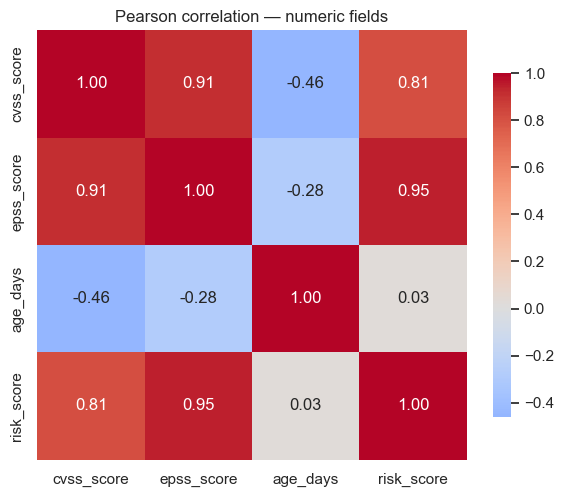

In [7]:
numeric_cols = ["cvss_score", "epss_score", "age_days", "risk_score"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson correlation — numeric fields")
fig.tight_layout()
plt.show()

## 6. Age distribution

`age_days` matters because the scoring formula caps its contribution at 365 days. Anything clustered at the cap is losing information to the cap — useful to know when arguing about whether the cap is too tight.

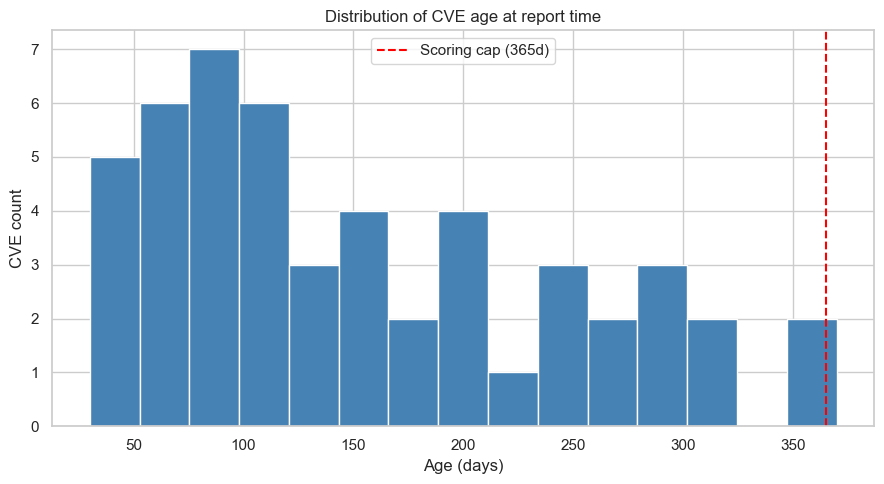

In [8]:
fig, ax = plt.subplots()
ax.hist(df["age_days"], bins=15, color="steelblue", edgecolor="white")
ax.axvline(365, color="red", linestyle="--", label="Scoring cap (365d)")
ax.set_xlabel("Age (days)")
ax.set_ylabel("CVE count")
ax.set_title("Distribution of CVE age at report time")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Vendor-level summary

Collapse per-CVE rows into per-vendor rows to see concentration. Row count × average risk × KEV share per vendor is the table most useful to someone prioritizing remediation at the team level.

In [9]:
vendor_summary = (
    df.groupby("vendor")
      .agg(
          cve_count=("cve_id", "count"),
          kev_count=("is_kev", "sum"),
          avg_risk=("risk_score", "mean"),
          max_risk=("risk_score", "max"),
          avg_epss=("epss_score", "mean"),
      )
      .round(2)
      .sort_values("avg_risk", ascending=False)
)
vendor_summary["kev_pct"] = (vendor_summary["kev_count"] / vendor_summary["cve_count"] * 100).round(0)
vendor_summary

,cve_count,kev_count,avg_risk,max_risk,avg_epss,kev_pct
vendor,,,,,,
oracle,10,4,7.60,11.88,0.48,40.0
microsoft,10,4,7.59,11.27,0.52,40.0
adobe,10,3,7.10,12.67,0.41,30.0
apache,10,1,5.78,14.42,0.28,10.0
cisco,10,0,4.58,5.67,0.16,0.0


## 8. KEV vs non-KEV comparison

Are KEV rows meaningfully different from non-KEV on the other dimensions (CVSS, EPSS, age)? If yes, KEV is adding information beyond what those features already encode; if no, it's redundant.

In [10]:
df.groupby("is_kev")[["cvss_score", "epss_score", "age_days", "risk_score"]].agg(["mean", "median"]).round(2)

cvss_score        epss_score        age_days        risk_score       
             mean median       mean median     mean median       mean median
is_kev                                                                      
False        5.81   5.90       0.22   0.18   157.76  135.0       4.98   4.70
True         9.11   9.25       0.86   0.88   148.75  105.0      11.44  11.18

## Analyst insights

Three takeaways from the analysis above — stated as what they *mean for operations*, not just what's in the numbers.

1. **KEV and high-EPSS signal overlap completely in this snapshot, which makes the KEV bonus (+2.0) a robustness bet rather than a coverage bet.** Every Critical-severity CVE here is both KEV-listed *and* has EPSS ≥ 0.85 — either filter alone catches the same cohort. The formula keeps KEV as a separate additive term so that *when* the signals diverge on future data (a KEV CVE with unexpectedly low EPSS, or vice versa), the pipeline still flags the union of both — but today, the two terms are double-counting.

2. **Critical risk concentrates in just two vendor/product stacks, which is actionable in a way per-CVE alerting is not.** `adobe/flash` (avg 9.3) and `oracle/java` (avg 8.8) are the only pairs above the 8.0 critical threshold, while the next eight sit below it. That means roughly two weeks of focused remediation work on those two stacks would cover the critical surface more effectively than triaging 50 individual CVE IDs in isolation — the product-level report (`report_product_daily`) is where prioritization conversations should start, with per-CVE drill-down as a follow-up.

3. **KEV-addition velocity has roughly doubled quarter-over-quarter, which threatens the current alert thresholds before it threatens storage.** Feb–Mar 2026 produced 5 new KEV entries vs. 4 across all of H2 2025. If that pace continues, the `high_vuln_count` product threshold (≥50 open vulns) and `high_avg_risk` threshold (≥7.0) will fire on noticeably more products, diluting alert signal well before the tables themselves grow inconvenient. Revisit those cutoffs on the next quarterly review, not on calendar schedule.